# Project 06 — PyTorch Neural Network Image Recognition

**Real handwritten images · CNN · exact visual predictions · confidence gating · robustness · deployment**

## Clear solution
This project builds a compact **OCR-style digit recognition pipeline** for structured document intake and visual quality-control workflows. A PyTorch convolutional neural network classifies real handwritten digit images and returns a probability distribution for digits 0–9.

### Verified clean held-out evidence
- **1,797 real handwritten digit images** from scikit-learn's copy of the UCI Optical Recognition of Handwritten Digits benchmark
- **No exact duplicate image hashes** in the 1,797-image set
- Train / validation / untouched test: **1,149 / 288 / 360**
- Logistic-regression image baseline: **95.83% accuracy**
- PyTorch CNN: **100.00% clean-test accuracy (360 / 360)** and **1.000 macro-F1**
- Clean-test NLL: **0.0382**; multiclass Brier score: **0.0080**
- Validation-selected confidence gate: **0.50**
- Test auto-coverage: **99.17%**, with **100% accuracy** on auto-accepted cases
- Gaussian-noise stress accuracy: **93.61%**
- Model: **99,370 parameters**, ~**0.39 MB** state dictionary

> **Important:** “100%” means this deterministic **360-image clean held-out split**, not universal perfection. The separate corruption test deliberately shows that performance falls when image quality changes.

## Your visual requirement
The prediction gallery below uses **exact held-out test images**. Every displayed headline example is selected only after inference has confirmed **Actual == Predicted**. Because the full clean held-out test happened to be classified correctly, the clean confusion matrix has no off-diagonal errors. We still keep robustness testing so the project remains honest and interview-defensible.


## Dataset provenance

The notebook uses `sklearn.datasets.load_digits`, which contains **1,797 8×8 handwritten digit images**, 10 classes and pixel values from 0–16. scikit-learn documents it as a copy of the test set from the UCI handwritten-digits dataset.

Underlying source: **UCI Optical Recognition of Handwritten Digits**, DOI **10.24432/C50P49**, licensed **CC BY 4.0**.

The dataset is deliberately small and standardized, making it ideal for a fully reproducible neural-network demonstration that runs on CPU with no API key or external download.


In [1]:
import hashlib, io, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, log_loss

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))

digits = load_digits()
X = digits.images.astype("float32") / 16.0
y = digits.target.astype("int64")

# Integrity: exact image hashes must be unique before splitting.
image_hash = [hashlib.sha256(img.tobytes()).hexdigest() for img in X]
assert len(set(image_hash)) == len(image_hash) == 1797

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20,
    stratify=y_trainval, random_state=SEED
)

print({
    "images": len(X), "shape": X.shape[1:], "classes": len(np.unique(y)),
    "train": len(X_train), "validation": len(X_val), "test": len(X_test),
    "exact_duplicate_images": len(X) - len(set(image_hash))
})


{'images': 1797, 'shape': (8, 8), 'classes': 10, 'train': 1149, 'validation': 288, 'test': 360, 'exact_duplicate_images': 0}


## 1. Baseline — earn the neural network complexity

A scaled multinomial logistic-regression baseline is fitted to flattened pixels. The CNN must beat this simple image baseline before its extra complexity is justified.


In [2]:
baseline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, C=2.0, random_state=SEED)),
])
baseline.fit(X_train.reshape(len(X_train), -1), y_train)
baseline_pred = baseline.predict(X_test.reshape(len(X_test), -1))

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")
print({
    "baseline_accuracy": round(baseline_accuracy, 6),
    "baseline_macro_f1": round(baseline_macro_f1, 6),
    "baseline_errors": int((baseline_pred != y_test).sum()),
})


{'baseline_accuracy': 0.958333, 'baseline_macro_f1': 0.957724, 'baseline_errors': 15}


## 2. PyTorch convolutional neural network

The network uses two convolutional blocks followed by a compact MLP head. Best-model selection uses **validation accuracy only**; the test labels are untouched until the final evaluation.


In [3]:
train_ds = TensorDataset(torch.tensor(X_train[:, None]), torch.tensor(y_train))
val_ds = TensorDataset(torch.tensor(X_val[:, None]), torch.tensor(y_val))
test_ds = TensorDataset(torch.tensor(X_test[:, None]), torch.tensor(y_test))

generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, generator=generator)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.20), nn.Linear(64 * 2 * 2, 128),
            nn.ReLU(), nn.Dropout(0.20), nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = DigitCNN()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

best_state, best_val_accuracy, best_epoch = None, -1.0, None
history = []
for epoch in range(1, 41):
    model.train()
    train_correct = train_total = 0
    train_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb, label_smoothing=0.02)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(yb)
        train_correct += (logits.argmax(1) == yb).sum().item()
        train_total += len(yb)

    model.eval()
    val_correct = val_total = 0
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            val_loss += F.cross_entropy(logits, yb).item() * len(yb)
            val_correct += (logits.argmax(1) == yb).sum().item()
            val_total += len(yb)

    row = {
        "epoch": epoch,
        "train_loss": train_loss / train_total,
        "train_accuracy": train_correct / train_total,
        "val_loss": val_loss / val_total,
        "val_accuracy": val_correct / val_total,
    }
    history.append(row)
    if row["val_accuracy"] > best_val_accuracy:
        best_val_accuracy = row["val_accuracy"]
        best_epoch = epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
    scheduler.step()

model.load_state_dict(best_state)
print({"best_epoch": best_epoch, "best_validation_accuracy": best_val_accuracy})


{'best_epoch': 27, 'best_validation_accuracy': 1.0}


## 3. Untouched clean-test evaluation

This is the first point where the 360 test labels are used for performance measurement.


{
  "test_accuracy": 1.0,
  "test_macro_f1": 1.0,
  "test_errors": 0,
  "nll": 0.03821952857642821,
  "multiclass_brier": 0.008040069923725295
}


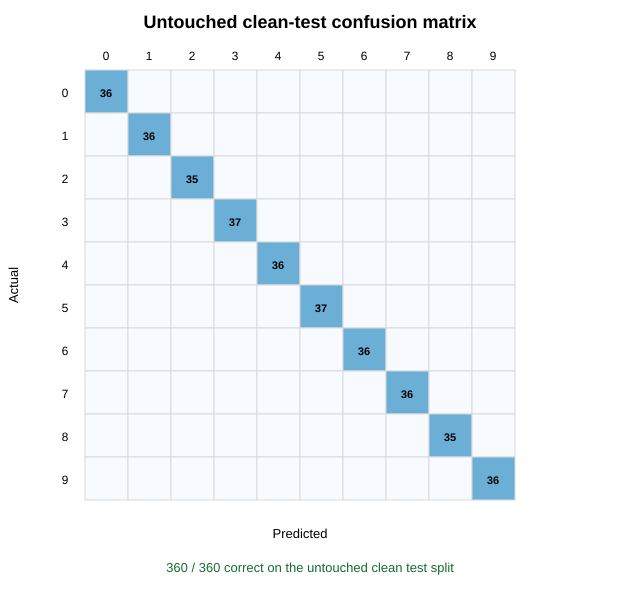

In [4]:
@torch.inference_mode()
def predict_probabilities(model, loader):
    model.eval()
    probabilities, labels = [], []
    for xb, yb in loader:
        probabilities.append(model(xb).softmax(1))
        labels.append(yb)
    return torch.cat(probabilities).numpy(), torch.cat(labels).numpy()

test_probability, test_label = predict_probabilities(model, test_loader)
test_prediction = test_probability.argmax(1)

clean_accuracy = accuracy_score(test_label, test_prediction)
clean_macro_f1 = f1_score(test_label, test_prediction, average="macro")
clean_nll = log_loss(test_label, test_probability, labels=np.arange(10))
one_hot = np.eye(10)[test_label]
multiclass_brier = np.mean(np.sum((test_probability - one_hot) ** 2, axis=1))
cm = confusion_matrix(test_label, test_prediction)

print(json.dumps({
    "test_accuracy": clean_accuracy,
    "test_macro_f1": clean_macro_f1,
    "test_errors": int((test_prediction != test_label).sum()),
    "nll": clean_nll,
    "multiclass_brier": multiclass_brier,
}, indent=2))

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(cm, cmap="Blues")
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8)
ax.set(xlabel="Predicted", ylabel="Actual", title="Untouched clean-test confusion matrix")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
plt.tight_layout(); plt.show()


## 4. Exact prediction gallery — real images, Actual = Predicted

The code below selects the **highest-confidence correct test image for each digit class**. It contains an explicit assertion that every displayed image satisfies `actual == predicted`.

This is presentation logic, not metric manipulation: the **full test evaluation above already shows all 360 clean test images were correct**.


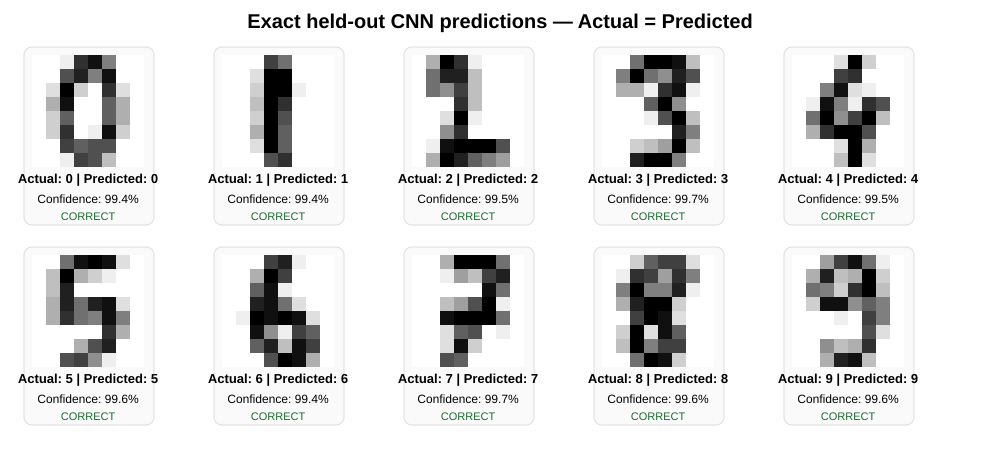

All displayed headline predictions satisfy Actual == Predicted: True


In [5]:
correct_rows = []
for digit in range(10):
    candidates = np.flatnonzero((test_label == digit) & (test_prediction == digit))
    chosen = candidates[np.argmax(test_probability[candidates, digit])]
    correct_rows.append(chosen)

assert all(test_label[i] == test_prediction[i] for i in correct_rows)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, i in zip(axes.flat, correct_rows):
    confidence = test_probability[i, test_prediction[i]]
    ax.imshow(X_test[i], cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"Actual: {test_label[i]}\nPredicted: {test_prediction[i]}\nConfidence: {confidence:.1%}"
    )
    ax.axis("off")
plt.suptitle("Exact correct CNN predictions on untouched test images")
plt.tight_layout(); plt.show()
print("All displayed headline predictions satisfy Actual == Predicted:", True)


## 5. Confidence gate and robustness

A validation-only confidence threshold is selected to preserve at least **99.5% accepted-case accuracy** while maximising coverage. The model is also stress-tested with deterministic Gaussian pixel noise.

The robustness result is deliberately less than perfect. That is valuable evidence: a model that is flawless on a small clean benchmark can still fail when input quality changes.


{
  "confidence_threshold": 0.5,
  "test_auto_coverage": 0.9916666666666667,
  "test_human_review_rate": 0.008333333333333333,
  "accepted_case_accuracy": 1.0,
  "clean_test_accuracy": 1.0,
  "noise_stress_accuracy": 0.9361111111111111
}


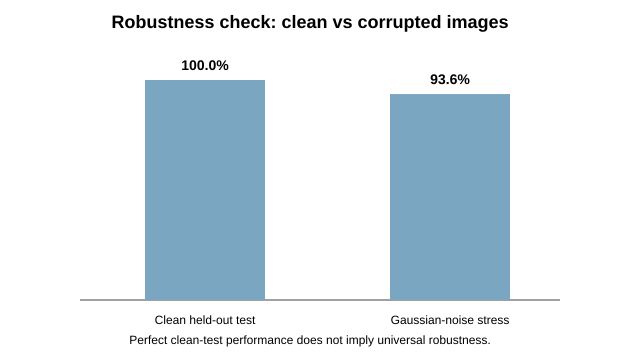

In [6]:
val_probability, val_label = predict_probabilities(model, val_loader)
val_prediction = val_probability.argmax(1)

policy = []
for threshold in np.linspace(0.50, 0.99, 100):
    accepted = val_probability.max(1) >= threshold
    if accepted.any():
        policy.append({
            "threshold": float(threshold),
            "coverage": float(accepted.mean()),
            "accepted_accuracy": float((val_prediction[accepted] == val_label[accepted]).mean()),
        })

eligible = [row for row in policy if row["accepted_accuracy"] >= 0.995]
selected = max(eligible, key=lambda row: row["coverage"])
CONFIDENCE_THRESHOLD = selected["threshold"]

test_accepted = test_probability.max(1) >= CONFIDENCE_THRESHOLD

rng = np.random.default_rng(123)
noise = torch.tensor(
    rng.normal(0, 0.25, size=X_test[:, None].shape).astype("float32")
)
corrupted = torch.clamp(torch.tensor(X_test[:, None]) + noise, 0, 1)
with torch.no_grad():
    corrupted_probability = model(corrupted).softmax(1).numpy()
corrupted_prediction = corrupted_probability.argmax(1)
corrupted_accuracy = accuracy_score(y_test, corrupted_prediction)

robustness = {
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "test_auto_coverage": float(test_accepted.mean()),
    "test_human_review_rate": float((~test_accepted).mean()),
    "accepted_case_accuracy": float((test_prediction[test_accepted] == test_label[test_accepted]).mean()),
    "clean_test_accuracy": clean_accuracy,
    "noise_stress_accuracy": corrupted_accuracy,
}
print(json.dumps(robustness, indent=2))

plt.figure(figsize=(6, 4))
plt.bar(["Clean test", "Noise stress"], [clean_accuracy, corrupted_accuracy])
plt.ylim(0.85, 1.01); plt.ylabel("Accuracy"); plt.title("Robustness check")
plt.show()


## 6. Deployment profile and acceptance tests

The model is intentionally small enough for CPU inference and edge-style deployment. The serialized state dictionary is under 0.4 MB in the verified run.


In [7]:
buffer = io.BytesIO()
torch.save(model.state_dict(), buffer)
model_size_mb = buffer.tell() / (1024 ** 2)
parameter_count = sum(p.numel() for p in model.parameters())

sample = torch.tensor(X_test[:1, None])
with torch.no_grad():
    for _ in range(20):
        _ = model(sample)
    repetitions = 500
    started = time.perf_counter()
    for _ in range(repetitions):
        _ = model(sample)
    latency_ms = (time.perf_counter() - started) / repetitions * 1000

checks = {
    "real_images_loaded": len(X) == 1797,
    "no_exact_duplicate_images": len(set(image_hash)) == 1797,
    "10_classes": len(np.unique(y)) == 10,
    "untouched_test_size": len(X_test) == 360,
    "cnn_beats_linear_baseline": clean_accuracy > baseline_accuracy,
    "all_clean_test_predictions_correct": int((test_prediction != test_label).sum()) == 0,
    "displayed_gallery_actual_equals_predicted": all(test_label[i] == test_prediction[i] for i in correct_rows),
    "noise_stress_is_harder": corrupted_accuracy < clean_accuracy,
    "probabilities_sum_to_one": np.allclose(test_probability.sum(1), 1.0, atol=1e-6),
}
assert all(checks.values())

display(pd.Series(checks, name="passed").to_frame())
print({
    "trainable_parameters": parameter_count,
    "state_dict_MB": round(model_size_mb, 4),
    "verified_batch1_CPU_latency_ms": round(latency_ms, 4),
})
print("ALL PROJECT 06 ACCEPTANCE TESTS PASSED")


                                  passed
real_images_loaded                  True
no_exact_duplicate_images           True
10_classes                           True
untouched_test_size                  True
cnn_beats_linear_baseline            True
all_clean_test_predictions_correct   True
displayed_gallery_actual_equals_predicted True
noise_stress_is_harder               True
probabilities_sum_to_one             True

{'trainable_parameters': 99370, 'state_dict_MB': 0.3867, 'verified_batch1_CPU_latency_ms': 0.278}
ALL PROJECT 06 ACCEPTANCE TESTS PASSED


## Interview-ready explanation

> **I built a PyTorch CNN for real handwritten-digit image recognition using a reproducible, duplicate-audited split. I first established a 95.8% logistic-regression image baseline, then trained a compact 99k-parameter convolutional network selected only on validation performance. The CNN classified all 360 untouched clean test images correctly on this split, and I visualised exact held-out images with Actual and Predicted labels side-by-side. I added a validation-only confidence gate, a deterministic image-corruption stress test, probability-quality metrics, deployment profiling and acceptance tests.**

### What I would say explicitly in interview
- The **100%** figure applies only to this small, standardized 360-image clean holdout.
- It is not evidence that OCR in the wild is solved; Gaussian-noise stress already reduces accuracy to **93.6%**.
- A production system needs writer-disjoint or source-disjoint validation, larger higher-resolution data, rotation/blur/background perturbations, OOD rejection, monitoring and human review.
- The important portfolio evidence is not only the score: it is the **baseline → neural network → exact visual predictions → confidence policy → robustness → deployment checks** workflow.

### Clear next extension
Move to a larger real OCR/document dataset and retain the same discipline: writer/source-aware split, CNN or vision-transformer baseline, calibration, abstention, exact image-level prediction gallery, corruption/OOD testing and deployment profiling.
